
# Data Wrangling



In this notebook, we will continue working with data — this time focusing on **data wrangling**, **handling missing values**, and **visualizing patterns**.

We will use the built-in **penguins** dataset from the Seaborn library to avoid any file setup issues.



## 1. What Is Data Wrangling?

**Data wrangling** (also called *data munging*) means transforming and cleaning raw data into a structured format that is easy to analyze.  
Typical operations include:
- Handling missing values  
- Filtering and sorting rows  
- Grouping data for summaries  
- Creating new calculated columns  

Think of it as organizing a messy spreadsheet into a clean, logical table that answers your questions.



## 2. Setup: Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Display settings
pd.set_option('display.precision', 2)
sns.set_theme(style="whitegrid")


## 3. Load the Penguins Dataset

We will use the `penguins` dataset from the Seaborn library.  
Each row represents one penguin and its measured characteristics (e.g., bill length, body mass, species, island, etc.).


In [ ]:
df = sns.load_dataset('penguins')
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Explore dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.23,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00



## 4. Exploring Missing Values

Let's check for missing data using `.isnull().sum()`.




### 4.1 Types of Missingness (Concept)

Not all missing values are the same. Understanding *why* data is missing helps you choose a strategy:

- **MCAR** (Missing Completely At Random): missingness is unrelated to any value (rare in practice).  
- **MAR** (Missing At Random): missingness depends on other observed variables (e.g., body mass missing more often for a certain island).  
- **MNAR** (Missing Not At Random): missingness depends on the value itself (e.g., very small bill length values are more likely to be missing).

> **Takeaway:** The less random the missingness, the more careful you must be with imputations.



### 4.2 Per-Column and Per-Row Missingness

Count missing values per **column** and per **row** to see the scope of the issue.



### Handling Missing Values

We can either **drop** missing values (remove rows) or **fill** them with a substitute (like the median or mean for numeric data).


In [ ]:
# Drop rows with any missing values
df_drop = df.dropna()
print("Rows before:", len(df))
print("Rows after dropna:", len(df_drop))


Rows before: 344
Rows after dropna: 333



> **Tip:** Always check how much data was missing before filling — replacing too much missing data can lead to misleading results.


In [ ]:
missing_per_col = df.isnull().sum().sort_values(ascending=False)
missing_per_col


,0
sex,11
bill_depth_mm,2
bill_length_mm,2
flipper_length_mm,2
body_mass_g,2
island,0
species,0


In [ ]:
# Percentage of missing per column
(missing_per_col / len(df) * 100).round(2)


,0
sex,3.20
bill_depth_mm,0.58
bill_length_mm,0.58
flipper_length_mm,0.58
body_mass_g,0.58
island,0.00
species,0.00



### 4.3 Drop vs Fill: When to Use Which?

- **Drop rows** when only a *small* fraction is missing and the rows look random (MCAR).  
- **Fill (impute)** when dropping would remove too much data, or when certain variables are essential.

> **Rule of thumb:** Always report how much data you dropped/filled and why!



### 4.4 Numeric Imputation Strategies

We already used the **median** (robust to outliers). Other options:
- **Mean**: simple, but sensitive to outliers.  
- **Per-group median/mean**: impute within each category (e.g., per species).  
- **Forward/Backward fill**: good for time series.

Below we show **per-group median** and **forward fill** examples.


In [ ]:
# Per-group median imputation example (by species)
df_group_imp = df.copy()
for col in ['bill_length_mm','bill_depth_mm', 'flipper_length_mm','body_mass_g']:
    df_group_imp[col] = df_group_imp.groupby('species')[col].transform(
        lambda s: s.fillna(s.median())
    )
df_group_imp.isnull().sum()


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,11



### 4.5 Categorical Imputation Strategies

For categorical features (like `sex`, `island`):
- Fill with a sentinel value such as `'Unknown'`.
- Or fill with the **mode** (most frequent category), optionally **per group**.

> **Tip:** After imputation, consider adding a boolean **indicator column** (e.g., `was_imputed`) so you can track which rows were filled.


In [ ]:
# Simple sentinel fill
df_sent = df_group_imp.copy()
df_sent['sex'] = df_sent['sex'].fillna('Unknown')
df_sent['sex'].value_counts(dropna=False)


,count
sex,
Male,168
Female,165
Unknown,11


In [ ]:
df_sent.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


## What is a Sentinel Fill?

A **sentinel value** is a special placeholder used to represent missing or unknown data, instead of leaving it as `NaN`.

For example, when working with categorical columns like `"sex"` or `"city"`, we can replace missing entries with a label such as `"Unknown"`.  
This is called a **sentinel fill**.

**Why use a sentinel fill?**
- Keeps missing categories visible in plots and tables.
- Avoids losing rows when you don’t want to drop them.
- Helps models and encoders treat “Unknown” as a valid but distinct category.

**When *not* to use it:**
- For numeric data, using sentinel numbers (e.g., `-999`) can distort calculations.  
  Use `NaN` or imputation (e.g., fill with median) instead.


### Choosing the Right Strategy for Many Missing Numerical Values

When a column has *too many missing numerical values*, dropping or simply filling them can bias your analysis.  
Here are some practical strategies:

1. **Diagnose the pattern**
   - Use `.isnull().mean()` to check the percentage of missing data per column.
   - Visualize with a heatmap to see if the missingness is random or systematic.

2. **Decide based on the percentage of missingness**

   | Missing % | Recommended Action |
   |------------|--------------------|
   | **< 5%**   | Simple imputation (mean or median) |
   | **5–30%**  | More careful imputation (median + domain knowledge or regression) |
   | **> 30–40%** | Consider dropping the column or creating a missingness indicator |

3. **Possible approaches**
   - **Simple imputation:**  
     `df['col'] = df['col'].fillna(df['col'].median())`
   - **Model-based imputation:** use `KNNImputer` or `IterativeImputer` to predict missing values using other features.
   - **Add a missing indicator:**



> **Checklist after imputation:**  
> 1) Re-check missingness with `.isnull().sum()`; 2) sanity-check summary stats; 3) document what you changed.



## 5. Basic Data Wrangling Operations

Let’s perform common operations such as filtering, grouping, and sorting.


In [ ]:
# Filter: Select only Adelie penguins
adelie = df_sent[df_sent['species'] == 'Adelie']
adelie.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,38.8,18.4,190.0,3700.0,Unknown
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



### Grouping and Aggregating Data

We can group data by a column (e.g., species) and compute summary statistics such as the mean or count.


In [ ]:
# Average body mass per species
species_mass = df_sent.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)
species_mass


,body_mass_g
species,
Gentoo,5075.40
Chinstrap,3733.09
Adelie,3700.66



### Multiple Aggregations

You can calculate more than one statistic at once using `.agg()`.


In [ ]:
# Mean and median of bill length and depth by species
agg_stats = df_sent.groupby('species')[['bill_length_mm', 'bill_depth_mm']].agg(['mean', 'median'])
agg_stats


bill_length_mm        bill_depth_mm       
                    mean median          mean median
species                                             
Adelie             38.79  38.80         18.35  18.40
Chinstrap          48.83  49.55         18.42  18.45
Gentoo             47.50  47.30         14.98  15.00


## 5.4 Safe Numeric Conversion

Sometimes numeric columns are accidentally loaded as text (e.g., `"123"` instead of `123`).  
Use `pd.to_numeric(..., errors='coerce')` to safely convert them — invalid entries become `NaN`, which you can later impute or drop.


In [ ]:
# Example: safe numeric conversion
df_sent['body_mass_g'] = pd.to_numeric(df_sent['body_mass_g'], errors='coerce')
df_sent['bill_length_mm'] = pd.to_numeric(df_sent['bill_length_mm'], errors='coerce')
df_sent.dtypes.head()


,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64



## 5.5 Combining Datasets (Merge)

Sometimes information is stored in multiple tables.  
For example, you might have one dataset with penguin measurements and another with lookup information such as **island-to-region** mapping.

To combine them, we can use **`pd.merge()`**, which works similarly to SQL joins.

- `inner` merge keeps only matching rows.  
- `left` merge keeps all rows from the left (main) DataFrame.


In [ ]:
# Create a small lookup table for island regions
island_region = pd.DataFrame({
    'island': ['Torgersen', 'Biscoe', 'Dream'],
    'region': ['North', 'South', 'West']
})



In [ ]:
# Merge with our penguin dataset
df_merged = pd.merge(df_sent, island_region, on='island', how='left')
df_merged.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,region
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,North
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,North
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,North
3,Adelie,Torgersen,38.8,18.4,190.0,3700.0,Unknown,North
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,North



> **Tip:**  
> - Always check that your merge column (`on='island'` here) exists in both DataFrames.  
> - After merging, verify that the number of rows looks correct and that no unintended duplication occurred.  
> - You can use `how='inner'`, `'left'`, `'right'`, or `'outer'` depending on which records you want to keep.



### Practice Exercise — Merge + Group + Plot

Now that we’ve merged our datasets, let’s put everything together:

1. Group the merged data by `region`.  
2. Calculate the **average body mass** of penguins per region.  
3. Visualize it using a simple bar chart.

This exercise combines **merging**, **grouping**, and **visualization** — three essential data wrangling skills.


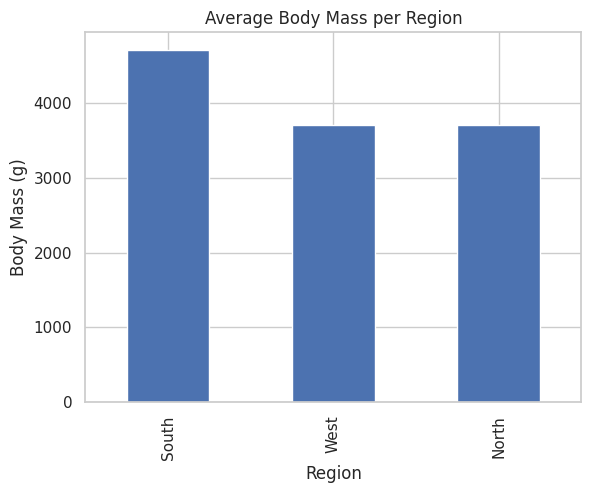

In [ ]:
# Group by region and compute mean body mass
region_mass = df_merged.groupby('region')['body_mass_g'].mean().sort_values(ascending=False)

# Plot as bar chart
region_mass.plot(kind='bar', title='Average Body Mass per Region', ylabel='Body Mass (g)', xlabel='Region')
plt.show()



> ✅ **Tip:**  
> This is a classic mini data analysis pattern:
> - Combine data from different sources (`merge`)  
> - Summarize it (`groupby`)  
> - Communicate results (`plot`)  
>
> These three steps appear in almost every real-world data science workflow.



## 5.6 Filtering Rows

**Filtering** lets us focus on subsets of data that match a condition.

Examples:
- Penguins heavier than 4000g
- Penguins measured on a specific island
- Rows where a column is not missing

We'll start with a simple numeric filter.


In [ ]:
# Filter penguins heavier than 4000g
heavy_penguins = df_sent[df_sent['body_mass_g'] > 4000]
heavy_penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Unknown
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
19,Adelie,Torgersen,46.0,21.5,194.0,4200.0,Male



## 5.7 Reshaping (Pivoting / Melting)

Reshaping means **changing the layout of your dataset** — reorganizing rows and columns to make data analysis or visualization easier.

In real projects, data can come in many shapes:
- Sometimes it’s **too wide** (many columns).
- Sometimes it’s **too long** (many rows).
- And sometimes, you need to **restructure** it to compute summaries or make better plots.

---

### 🔄 **Pivoting**

**Pivoting** converts *rows into columns* — often used to create summary tables or matrices.

Example use case:
- You have average body mass for penguins by `species` and `sex`.
- You want each sex to appear as a separate column for easier comparison.

```python
pivot = df_filled.pivot_table(
    values='body_mass_g',
    index='species',
    columns='sex',
    aggfunc='mean'
)
pivot
```

**Result:**

| species | FEMALE | MALE |
|----------|---------|-------|
| Adelie   | 3368.8  | 4043.5 |
| Chinstrap| 3527.5  | 3939.6 |
| Gentoo   | 4680.0  | 5485.8 |

This layout makes it much easier to compare **average body mass** across both `species` and `sex`.

---

### 🔁 **Melting**

**Melting** does the opposite — it converts *columns into rows*.

It’s often used to make a wide table “tidy,” meaning every variable has its own column and each observation has its own row.

Example:
```python
df_melted = pivot.reset_index().melt(id_vars='species', value_name='mean_body_mass')
df_melted.head()
```

**Result:**

| species | sex | mean_body_mass |
|----------|-----|----------------|
| Adelie   | FEMALE | 3368.8 |
| Adelie   | MALE | 4043.5 |
| ... | ... | ... |

Melting is useful for:
- Plotting with libraries like **Seaborn**, which expect data in long (tidy) format.
- Converting summarized tables back into analyzable datasets.

---

### 💡 **Key Takeaway**

| Operation | Direction | Use Case |
|------------|------------|----------|
| **Pivoting** | Rows → Columns | Create summary tables for comparison |
| **Melting** | Columns → Rows | Prepare data for plotting or analysis |

> ✅ **Rule of Thumb:**  
> - Use `pivot()` or `pivot_table()` to **summarize and compare**.  
> - Use `melt()` to **unpack and tidy**.

In [ ]:
# Pivot table: average body mass by species (rows) and sex (columns)
pivot = df_sent.pivot_table(values='body_mass_g', index='species', columns='sex', aggfunc='mean')
pivot


sex,Female,Male,Unknown
species,,,
Adelie,3368.84,4043.49,3566.67
Chinstrap,3527.21,3938.97,NaN
Gentoo,4679.74,5484.84,4670.00



## 6. Basic Data Visualizations

Visualization helps you **see** patterns that might not be obvious from tables.



> **Note on Visualization Overlap:**  
> This notebook keeps visualization **minimal** (one bar chart in the main flow).  
> You practiced plotting foundations in Notebook 1, so here we focus on **wrangling and missing values**.  
> The scatter plot is included in the **Appendix** as an optional extension.



### Bar Chart: Average Body Mass per Species


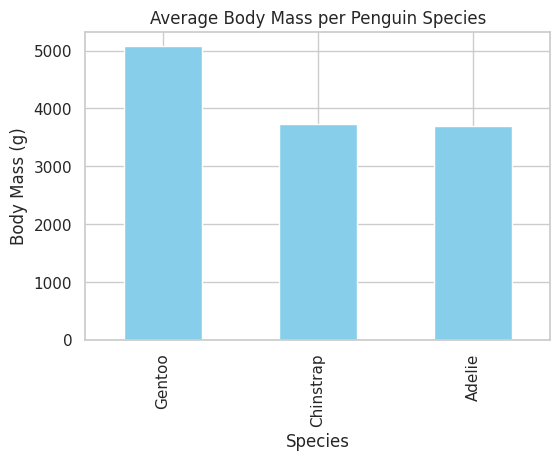

In [ ]:
plt.figure(figsize=(6,4))
species_mass.plot(kind='bar', color='skyblue')
plt.title('Average Body Mass per Penguin Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()


## Appendix (Optional): Scatter Plot — Bill Length vs Bill Depth

This plot explores the relationship between two numeric variables. Use it if you have time or as homework.

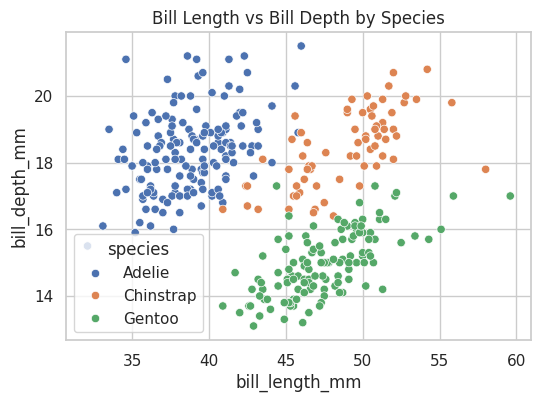

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_sent, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Bill Length vs Bill Depth by Species')
plt.show()



> **Tip:** When working with categorical variables, use color (`hue`) to compare groups in one chart.



## 7. Mini Challenge: Practice Data Wrangling and Visualization

Try the following challenge to reinforce what you learned:

1. Group the dataset by `island` instead of `species`.  
2. Compute the **average body mass** per island.  
3. Sort the result in descending order.  
4. Plot the result as a **bar chart**.

> Bonus: Add the chart title “Average Body Mass per Island” and label axes clearly.



## 9. Save the Cleaned Dataset

It's good practice to save your cleaned/merged dataset for future analysis or sharing.


In [ ]:
# Save the cleaned dataset (merged and imputed) to a CSV file
df_merged.to_csv('penguins_cleaned.csv', index=False)
print("Cleaned dataset saved as 'penguins_cleaned.csv'")


Cleaned dataset saved as 'penguins_cleaned.csv'



## 8. Wrap-up and Best Practices

**In this notebook, you learned:**
- How to check and handle missing values (`dropna`, `fillna`)
- How to perform grouping and aggregation (`groupby`, `agg`)
- How to visualize simple summaries with bar and scatter plots

**Best practices recap:**
- Always inspect missing values before cleaning.
- Use the **median** for numeric imputations (robust to outliers).
- Use `'Unknown'` for categorical missing values if few are missing.
- Label your plots — titles and axes make them understandable.

**Next steps:**  
In future sessions, you’ll learn how to combine multiple datasets, create calculated features, and use advanced visualization tools for storytelling.
